<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


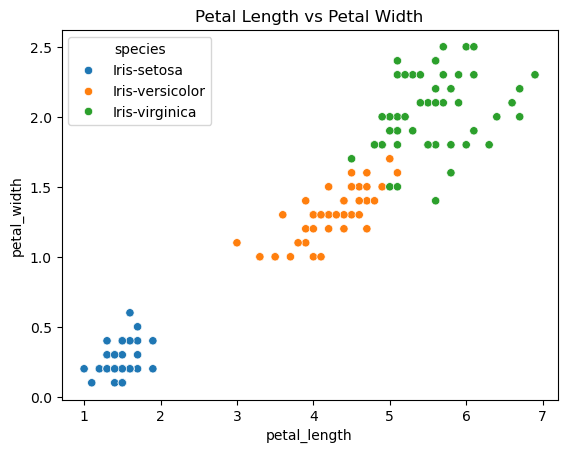

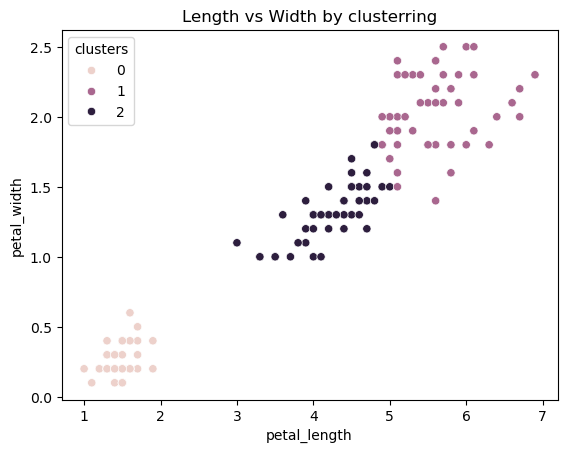

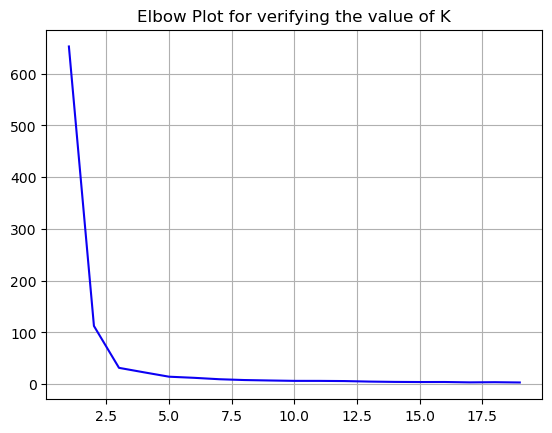

In [35]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
df=pd.read_csv(r'IRIS.csv')
print(df.info())
data_working=df[['petal_length','petal_width','species']]
plt.title("Petal Length vs Petal Width")
sns.scatterplot(data=data_working,x='petal_length',y='petal_width',hue='species')
plt.show()
km=KMeans(n_clusters=3,init='k-means++')
y_pred=km.fit_predict(data_working.drop('species',axis='columns'))
data_working['clusters']=y_pred
data_working.drop('species',axis='columns')
#print(data_working.info())
plt.title("Length vs Width by clusterring")
sns.scatterplot(data=data_working,x='petal_length',y='petal_width',hue='clusters')
plt.show()
#for elbow plot
k_rng=range(1,20)
sse=[]
for k in k_rng:
    km=KMeans(n_clusters=k)
    km.fit_predict(data_working.drop('species',axis='columns'))
    sse.append(km.inertia_)
plt.title("Elbow Plot for verifying the value of K")
plt.grid()
sns.lineplot(x=k_rng,y=sse,markers='O',color="#0C00F3")
plt.show()